In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def xyz(filein, n):
    xyz = []
    with open(filein, 'r') as fin:
        for line in fin:
            if line.startswith("ATOM") and len(xyz) < n:
                x = float(line[30:38].strip())  # X coordinate
                y = float(line[38:46].strip())  # Y coordinate
                z = float(line[46:54].strip())  # Z coordinate
                xyz.append([x, y, z])
    return np.array(xyz)
            

In [1]:
# The rotation axis is parallel to the z-axis, thus, only the x and y coordinates are considered. And a center point is aquired instead of an axis.
def get_center(pdb_1, pdb_2):
    # 10000 atoms
    xyz_1 = xyz(pdb_1, 10000)
    xyz_2 = xyz(pdb_2, 10000)

    xy_1 = xyz_1[:, :2]
    xy_2 = xyz_2[:, :2]
    # Rotate counterclockwise around the z-axis by 45 degrees, right multiplied
    A = np.array([np.cos(np.pi/4), np.sin(np.pi/4), -np.sin(np.pi/4), np.cos(np.pi/4)]).reshape(2, 2)
    B = np.linalg.inv(A - np.eye(2))
    # Rotation center
    c = (xy_1@A - xy_2)@B

    return c

In [4]:
c_dilated = get_center("dilated/sub1.pdb", "dilated/sub2.pdb")
c_constricted = get_center("constricted/sub1.pdb", "constricted/sub2.pdb")

In [6]:
print(f"dilated: {c_dilated.mean(axis=0)}")
print(f"constricted: {c_constricted.mean(axis=0)}")

dilated: [993.59997797 993.5999673 ]
constricted: [970.55994069 970.55994065]


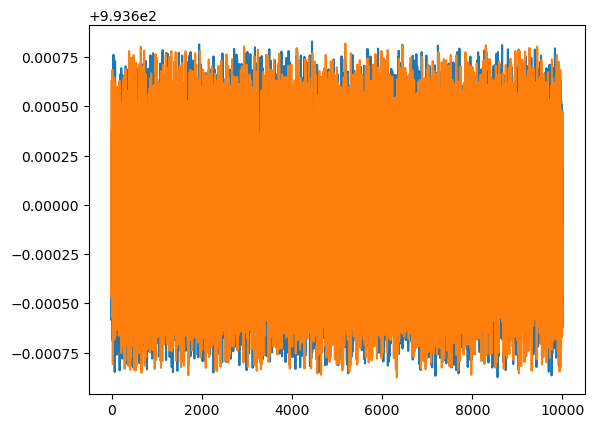

In [7]:
plt.plot(c_dilated)

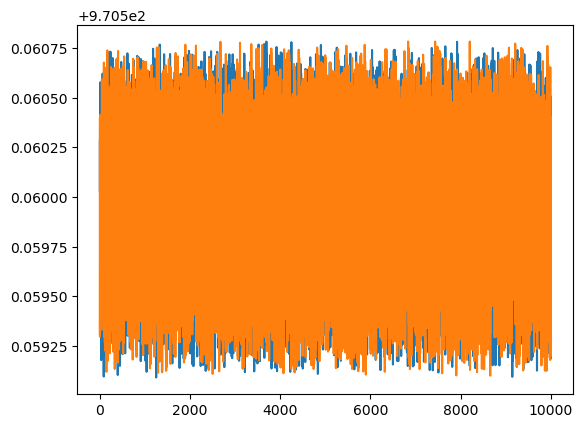

In [8]:
plt.plot(c_constricted)